# 02: Data Analysis and Visualization

## Objectives
- Analyze data distribution across classes
- Visualize sample images from each class
- Check image properties (size, format)
- Identify potential data issues

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Configuration
DATA_DIR = Path('./data')
FOOD10_DIR = DATA_DIR / 'food10'

# Updated selected classes (only available ones from Food-101)
SELECTED_CLASSES = [
    'pizza', 'hamburger', 'hot_dog', 'french_fries',
    'ice_cream', 'omelette', 'pancakes', 'ramen', 'steak',
    'fried_rice'  # Replaced sushi with fried_rice (available in Food-101)
]

print(f"Food-10 directory: {FOOD10_DIR}")
print(f"Classes: {len(SELECTED_CLASSES)}")
print(f"Classes: {SELECTED_CLASSES}")

# Check if data exists
if not FOOD10_DIR.exists():
    print(f"\n⚠️  WARNING: Food-10 directory not found!")
    print(f"Please run 01_Data_Preparation.ipynb first to download and prepare the data.")
    print(f"Expected location: {FOOD10_DIR}")
else:
    print(f"\n✅ Food-10 directory found!")

Food-10 directory: data\food10
Classes: 10
Classes: ['pizza', 'hamburger', 'hot_dog', 'french_fries', 'ice_cream', 'omelette', 'pancakes', 'ramen', 'steak', 'fried_rice']

✅ Food-10 directory found!


In [3]:
def load_dataset_info():
    """Load dataset information and statistics"""
    dataset_info = {
        'train': defaultdict(list),
        'test': defaultdict(list)
    }
    
    for split in ['train', 'test']:
        split_dir = FOOD10_DIR / split
        
        if not split_dir.exists():
            print(f"Warning: {split_dir} does not exist!")
            continue
        
        for class_name in SELECTED_CLASSES:
            class_dir = split_dir / class_name
            if class_dir.exists():
                images = list(class_dir.glob('*.jpg'))
                dataset_info[split][class_name] = images
            else:
                print(f"Warning: {class_dir} does not exist!")
    
    return dataset_info

dataset_info = load_dataset_info()

# Print basic statistics
print("Dataset Overview:")
print("=" * 40)
for split in ['train', 'test']:
    total_images = sum(len(images) for images in dataset_info[split].values())
    print(f"{split}: {total_images} images")
    for class_name, images in dataset_info[split].items():
        print(f"  {class_name}: {len(images)}")

Dataset Overview:
train: 6309 images
  pizza: 750
  hamburger: 750
  hot_dog: 750
  french_fries: 750
  ice_cream: 750
  omelette: 309
  pancakes: 750
  ramen: 750
  steak: 750
test: 2104 images
  pizza: 250
  hamburger: 250
  hot_dog: 250
  french_fries: 250
  ice_cream: 250
  omelette: 104
  pancakes: 250
  ramen: 250
  steak: 250


## Step 2: Data Distribution Analysis

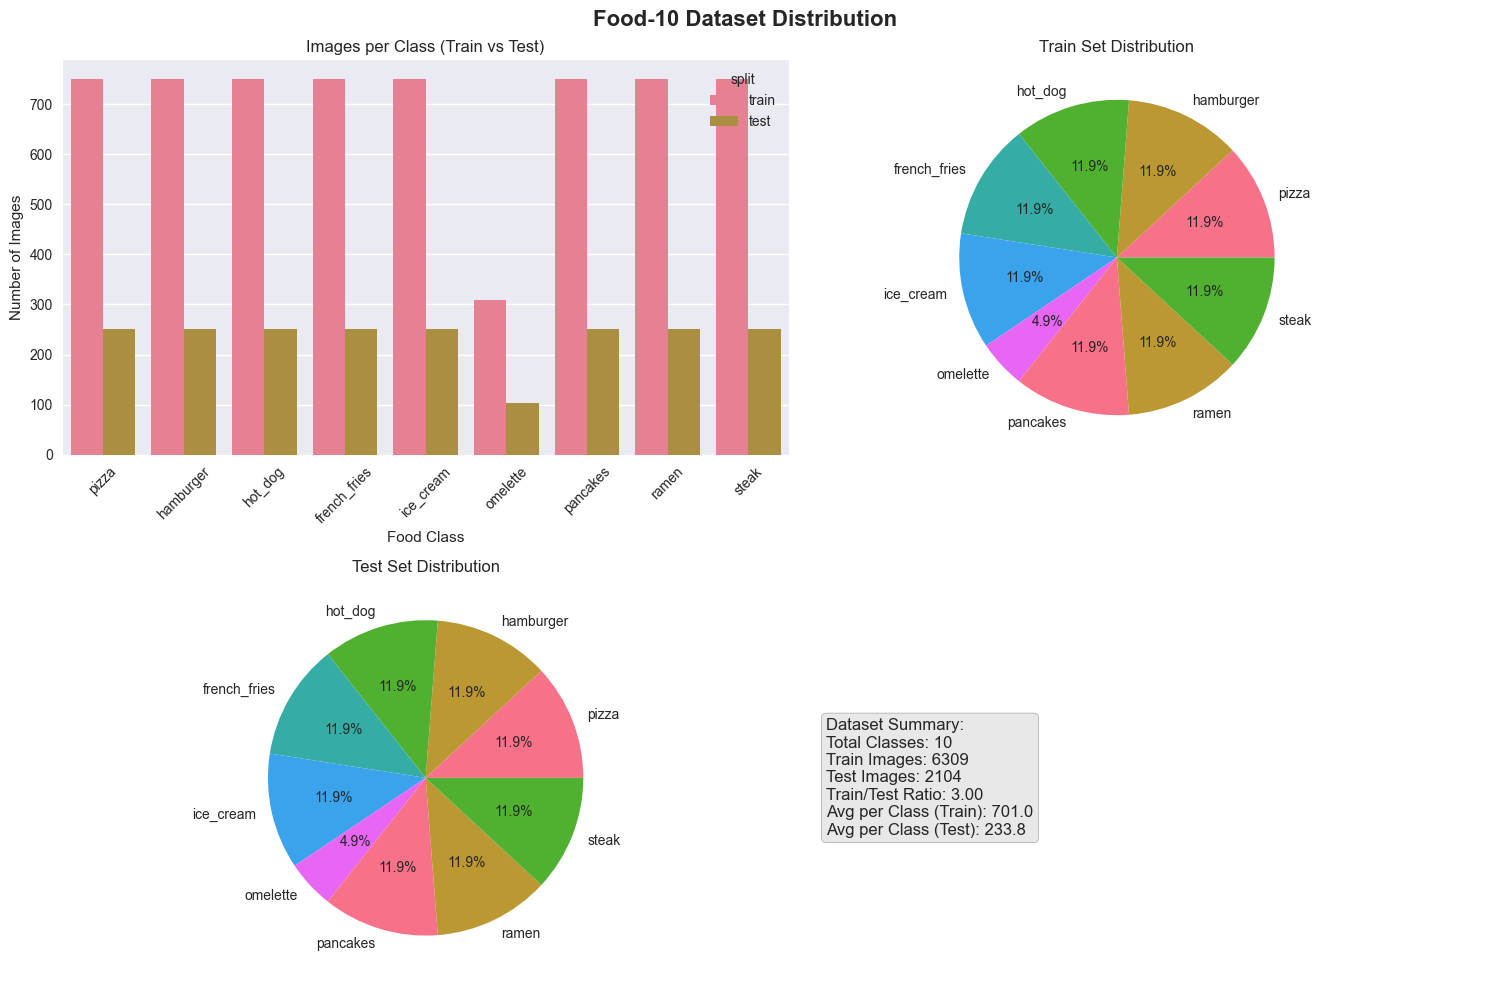

In [4]:
def analyze_data_distribution():
    """Analyze and visualize data distribution"""
    
    # Create distribution dataframe
    dist_data = []
    
    for split in ['train', 'test']:
        for class_name, images in dataset_info[split].items():
            dist_data.append({
                'split': split,
                'class': class_name,
                'count': len(images)
            })
    
    df_dist = pd.DataFrame(dist_data)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Food-10 Dataset Distribution', fontsize=16, fontweight='bold')
    
    # 1. Bar plot by class and split
    sns.barplot(data=df_dist, x='class', y='count', hue='split', ax=axes[0,0])
    axes[0,0].set_title('Images per Class (Train vs Test)')
    axes[0,0].set_xlabel('Food Class')
    axes[0,0].set_ylabel('Number of Images')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Pie chart for train set
    train_counts = df_dist[df_dist['split'] == 'train'].set_index('class')['count']
    axes[0,1].pie(train_counts.values, labels=train_counts.index, autopct='%1.1f%%')
    axes[0,1].set_title('Train Set Distribution')
    
    # 3. Pie chart for test set
    test_counts = df_dist[df_dist['split'] == 'test'].set_index('class')['count']
    axes[1,0].pie(test_counts.values, labels=test_counts.index, autopct='%1.1f%%')
    axes[1,0].set_title('Test Set Distribution')
    
    # 4. Summary statistics
    summary_text = f"""Dataset Summary:
Total Classes: {len(SELECTED_CLASSES)}
Train Images: {df_dist[df_dist['split'] == 'train']['count'].sum()}
Test Images: {df_dist[df_dist['split'] == 'test']['count'].sum()}
Train/Test Ratio: {df_dist[df_dist['split'] == 'train']['count'].sum() / df_dist[df_dist['split'] == 'test']['count'].sum():.2f}
Avg per Class (Train): {df_dist[df_dist['split'] == 'train']['count'].mean():.1f}
Avg per Class (Test): {df_dist[df_dist['split'] == 'test']['count'].mean():.1f}"""
    
    axes[1,1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return df_dist

df_distribution = analyze_data_distribution()

## Step 3: Image Properties Analysis

Analyzing 90 sample images...


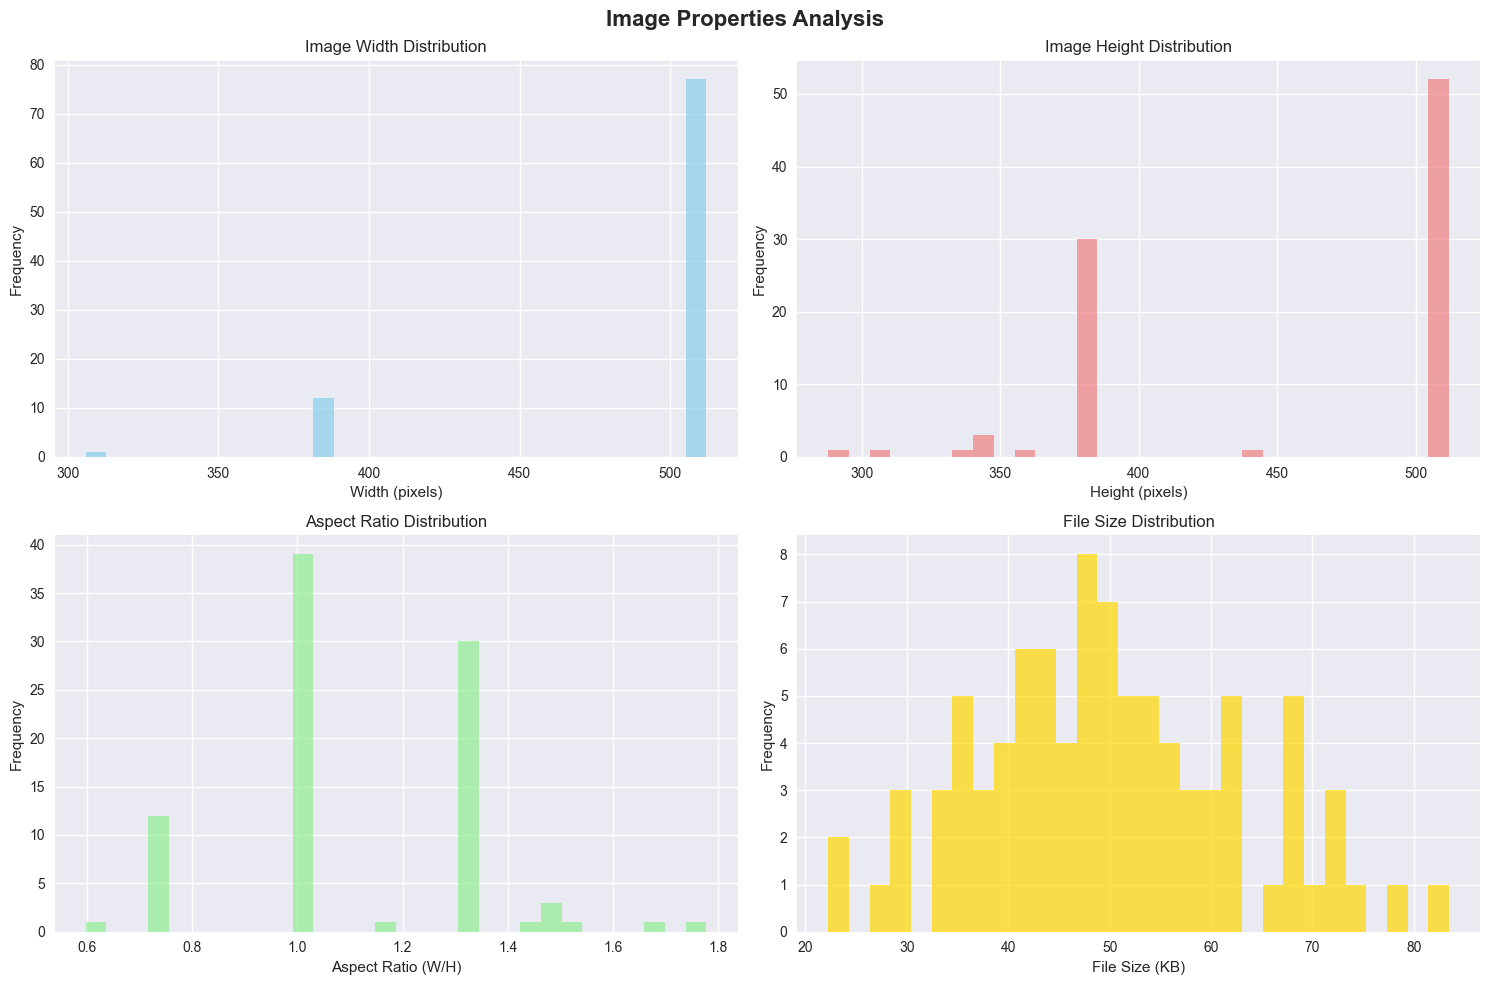


Image Properties Statistics:
Width: 492.6 ± 47.9 pixels
Height: 454.3 ± 69.5 pixels
Aspect Ratio: 1.12 ± 0.24
File Size: 49.9 ± 12.7 KB


In [5]:
def analyze_image_properties():
    """Analyze image properties (size, format, etc.)"""
    
    image_stats = {
        'width': [],
        'height': [],
        'aspect_ratio': [],
        'file_size': []
    }
    
    # Sample images from each class
    sample_images = []
    
    for split in ['train', 'test']:
        for class_name, images in dataset_info[split].items():
            if images:
                # Sample up to 5 images per class
                sampled = random.sample(images, min(5, len(images)))
                sample_images.extend([(img_path, class_name, split) for img_path in sampled])
    
    print(f"Analyzing {len(sample_images)} sample images...")
    
    for img_path, class_name, split in sample_images:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                aspect_ratio = width / height
                file_size = img_path.stat().st_size / 1024  # KB
                
                image_stats['width'].append(width)
                image_stats['height'].append(height)
                image_stats['aspect_ratio'].append(aspect_ratio)
                image_stats['file_size'].append(file_size)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Image Properties Analysis', fontsize=16, fontweight='bold')
    
    # Width distribution
    axes[0,0].hist(image_stats['width'], bins=30, alpha=0.7, color='skyblue')
    axes[0,0].set_title('Image Width Distribution')
    axes[0,0].set_xlabel('Width (pixels)')
    axes[0,0].set_ylabel('Frequency')
    
    # Height distribution
    axes[0,1].hist(image_stats['height'], bins=30, alpha=0.7, color='lightcoral')
    axes[0,1].set_title('Image Height Distribution')
    axes[0,1].set_xlabel('Height (pixels)')
    axes[0,1].set_ylabel('Frequency')
    
    # Aspect ratio distribution
    axes[1,0].hist(image_stats['aspect_ratio'], bins=30, alpha=0.7, color='lightgreen')
    axes[1,0].set_title('Aspect Ratio Distribution')
    axes[1,0].set_xlabel('Aspect Ratio (W/H)')
    axes[1,0].set_ylabel('Frequency')
    
    # File size distribution
    axes[1,1].hist(image_stats['file_size'], bins=30, alpha=0.7, color='gold')
    axes[1,1].set_title('File Size Distribution')
    axes[1,1].set_xlabel('File Size (KB)')
    axes[1,1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nImage Properties Statistics:")
    print("=" * 40)
    print(f"Width: {np.mean(image_stats['width']):.1f} ± {np.std(image_stats['width']):.1f} pixels")
    print(f"Height: {np.mean(image_stats['height']):.1f} ± {np.std(image_stats['height']):.1f} pixels")
    print(f"Aspect Ratio: {np.mean(image_stats['aspect_ratio']):.2f} ± {np.std(image_stats['aspect_ratio']):.2f}")
    print(f"File Size: {np.mean(image_stats['file_size']):.1f} ± {np.std(image_stats['file_size']):.1f} KB")
    
    return image_stats

image_stats = analyze_image_properties()

## Step 4: Visualize Sample Images

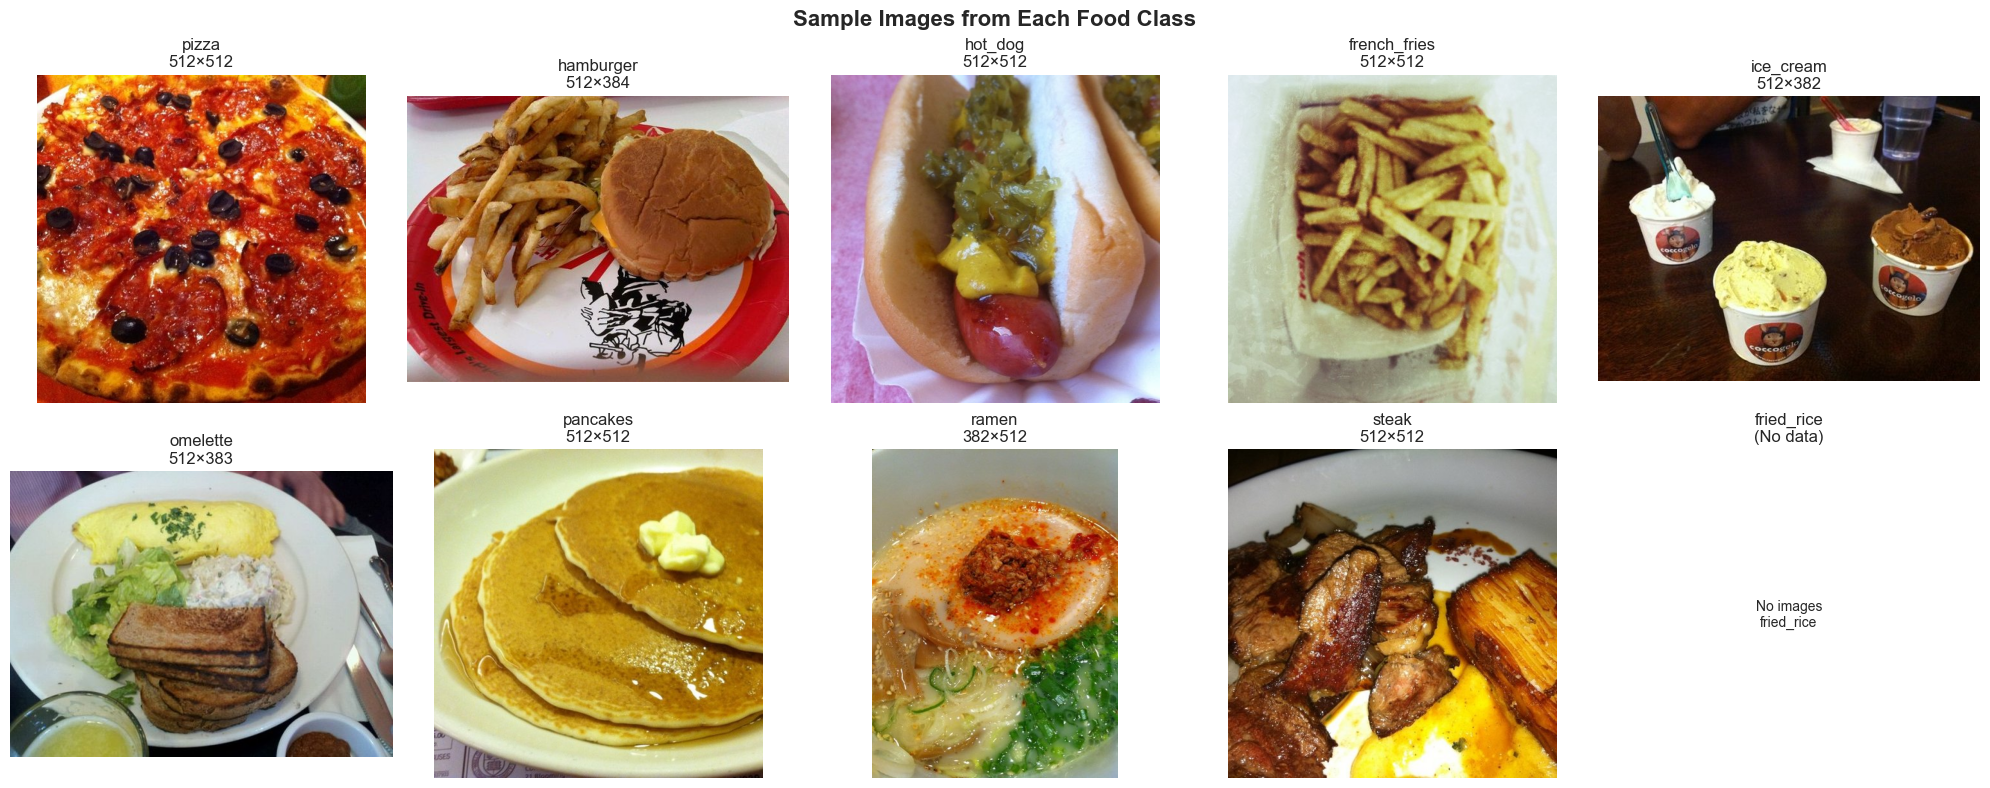

In [6]:
def visualize_sample_images():
    """Visualize sample images from each class"""
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Sample Images from Each Food Class', fontsize=16, fontweight='bold')
    
    for i, class_name in enumerate(SELECTED_CLASSES):
        row = i // 5
        col = i % 5
        ax = axes[row, col]
        
        # Get sample images from train set
        train_images = dataset_info['train'].get(class_name, [])
        
        if train_images:
            # Select a random image
            img_path = random.choice(train_images)
            
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f"{class_name}\n{img.size[0]}×{img.size[1]}")
            except Exception as e:
                ax.text(0.5, 0.5, f"Error loading\n{class_name}", 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"{class_name}\n(Error)")
        else:
            ax.text(0.5, 0.5, f"No images\n{class_name}", 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{class_name}\n(No data)")
        
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_sample_images()

## Step 5: Class-wise Detailed Analysis

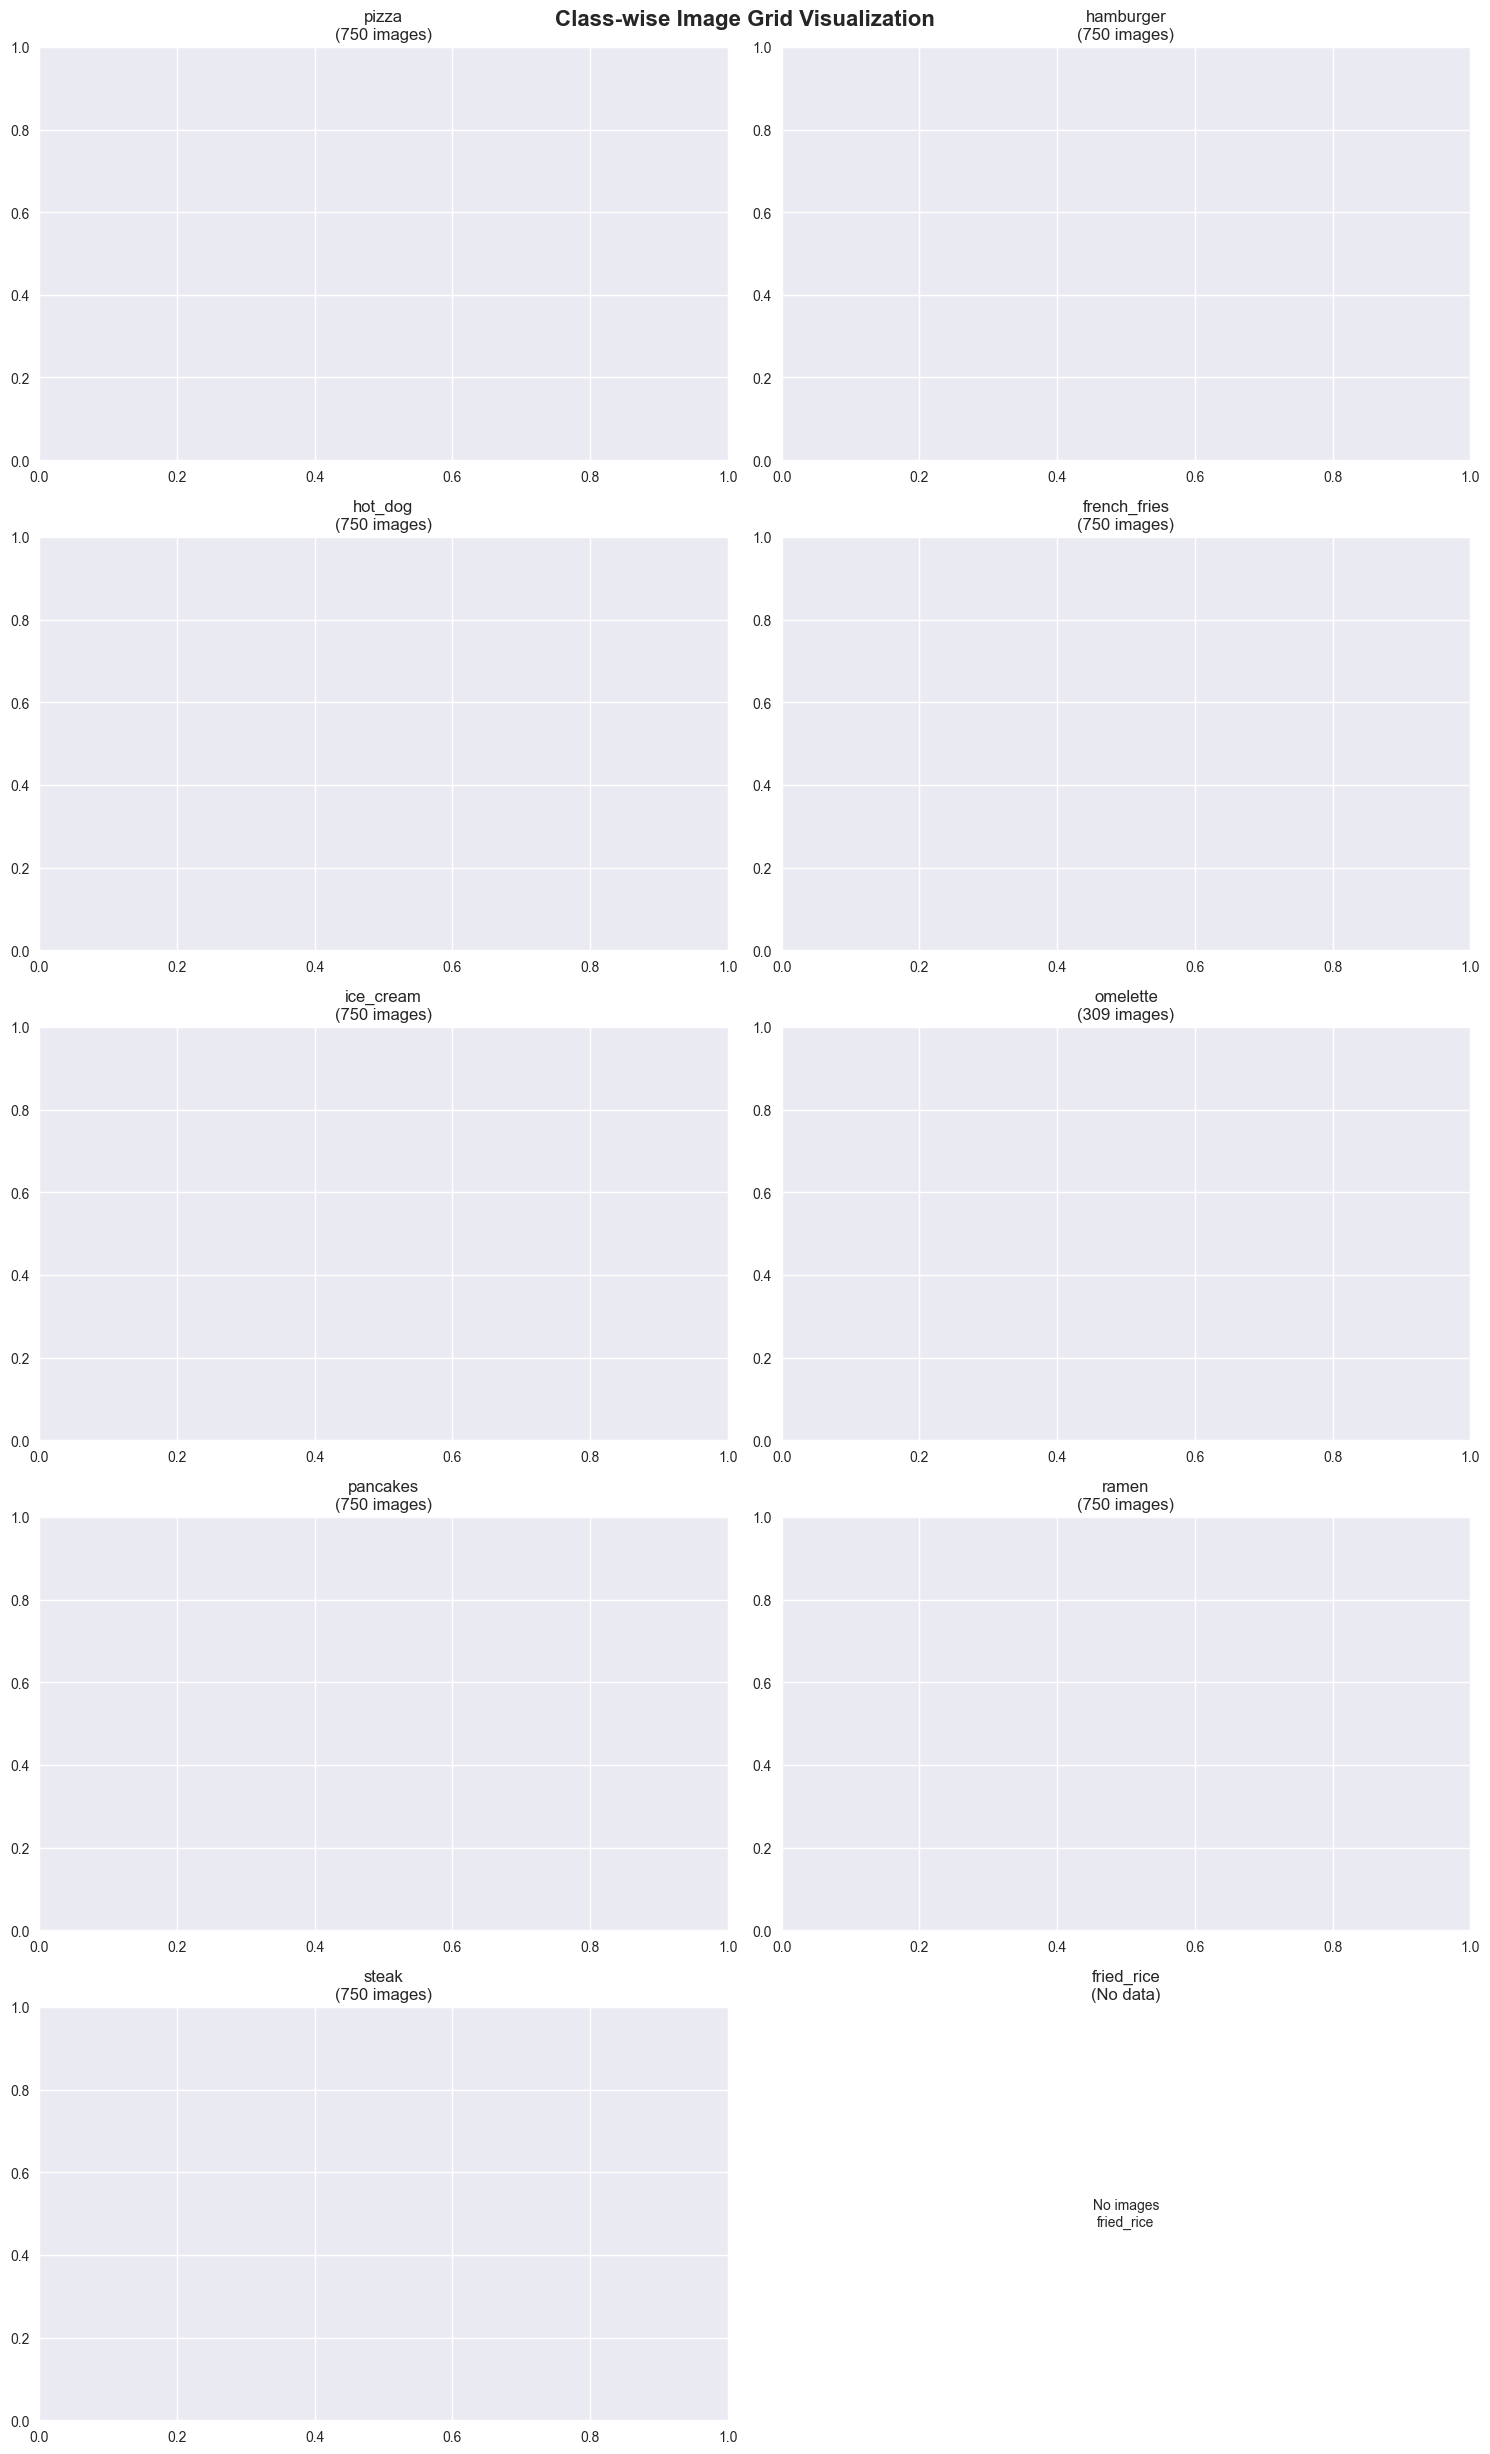

In [7]:
def class_wise_analysis():
    """Detailed analysis for each class"""
    
    fig, axes = plt.subplots(5, 2, figsize=(15, 25))
    fig.suptitle('Class-wise Image Grid Visualization', fontsize=16, fontweight='bold')
    
    for i, class_name in enumerate(SELECTED_CLASSES):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        
        # Get sample images from train set
        train_images = dataset_info['train'].get(class_name, [])
        
        if train_images:
            # Create a grid of sample images
            n_samples = min(16, len(train_images))
            sampled_images = random.sample(train_images, n_samples)
            
            # Create subgrid
            grid_size = int(np.ceil(np.sqrt(n_samples)))
            
            for j, img_path in enumerate(sampled_images):
                sub_row = j // grid_size
                sub_col = j % grid_size
                
                # Create subplot for each image
                sub_ax = plt.subplot2grid((5, 2), (row, col))
                
                if j == 0:  # Only show the first image as representative
                    try:
                        img = Image.open(img_path)
                        ax.imshow(img)
                        ax.set_title(f"{class_name}\n({len(train_images)} images)")
                    except Exception as e:
                        ax.text(0.5, 0.5, f"Error\n{class_name}", 
                               ha='center', va='center', transform=ax.transAxes)
                        ax.set_title(f"{class_name}\n(Error)")
                    break
        else:
            ax.text(0.5, 0.5, f"No images\n{class_name}", 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{class_name}\n(No data)")
        
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

class_wise_analysis()

## Step 6: Data Quality Check

In [8]:
def data_quality_check():
    """Check for data quality issues"""
    
    quality_issues = {
        'corrupted_files': [],
        'very_small_images': [],
        'very_large_images': [],
        'extreme_aspect_ratios': []
    }
    
    print("Performing data quality check...")
    
    for split in ['train', 'test']:
        for class_name, images in dataset_info[split].items():
            for img_path in images:
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        aspect_ratio = width / height
                        
                        # Check for very small images
                        if width < 100 or height < 100:
                            quality_issues['very_small_images'].append((img_path, width, height))
                        
                        # Check for very large images
                        if width > 1000 or height > 1000:
                            quality_issues['very_large_images'].append((img_path, width, height))
                        
                        # Check for extreme aspect ratios
                        if aspect_ratio < 0.5 or aspect_ratio > 2.0:
                            quality_issues['extreme_aspect_ratios'].append((img_path, aspect_ratio))
                            
                except Exception as e:
                    quality_issues['corrupted_files'].append((img_path, str(e)))
    
    # Report findings
    print("\nData Quality Report:")
    print("=" * 40)
    print(f"Corrupted files: {len(quality_issues['corrupted_files'])}")
    print(f"Very small images (<100px): {len(quality_issues['very_small_images'])}")
    print(f"Very large images (>1000px): {len(quality_issues['very_large_images'])}")
    print(f"Extreme aspect ratios: {len(quality_issues['extreme_aspect_ratios'])}")
    
    return quality_issues

quality_issues = data_quality_check()

Performing data quality check...

Data Quality Report:
Corrupted files: 1
Very small images (<100px): 0
Very large images (>1000px): 0
Extreme aspect ratios: 5


## Summary

In [9]:
print("\n" + "=" * 50)
print("DATA ANALYSIS SUMMARY")
print("=" * 50)
print(f"✅ Dataset distribution analyzed")
print(f"✅ Image properties examined")
print(f"✅ Sample images visualized")
print(f"✅ Class-wise analysis completed")
print(f"✅ Data quality check performed")

total_train = sum(len(images) for images in dataset_info['train'].values())
total_test = sum(len(images) for images in dataset_info['test'].values())

print(f"\nDataset Statistics:")
print(f"- Total training images: {total_train}")
print(f"- Total test images: {total_test}")
print(f"- Number of classes: {len(SELECTED_CLASSES)}")
print(f"- Average images per class: {(total_train + total_test) / len(SELECTED_CLASSES):.1f}")

print("\nNext steps:")
print("1. Run 03_Model_Training.ipynb for model training")
print("2. Consider data augmentation based on analysis")
print("3. Address any data quality issues if found")


DATA ANALYSIS SUMMARY
✅ Dataset distribution analyzed
✅ Image properties examined
✅ Sample images visualized
✅ Class-wise analysis completed
✅ Data quality check performed

Dataset Statistics:
- Total training images: 6309
- Total test images: 2104
- Number of classes: 10
- Average images per class: 841.3

Next steps:
1. Run 03_Model_Training.ipynb for model training
2. Consider data augmentation based on analysis
3. Address any data quality issues if found
